# CNN Explained: Klasifikasi Sampah dengan PyTorch

**Cara Kerja CNN dalam Satu Alur**

Notebook ini menjelaskan dan mengimplementasikan Convolutional Neural Network (CNN) untuk klasifikasi gambar sampah ke dalam 6 kategori (sesuai dataset **TrashType_Image_Dataset**): **cardboard, glass, metal, paper, plastic, trash**.

Alur yang dibahas:

```
Input -> Conv -> ReLU -> Pool -> Flatten -> FC -> Output
```

Setiap tahap dijelaskan secara konsep (markdown) sekaligus dibuktikan dengan kode dan visualisasi langsung pada data nyata.

---

## Struktur Dataset yang Digunakan

Dataset disusun dalam folder per kelas (format `ImageFolder` PyTorch):

```
TrashType_Image_Dataset/
├── cardboard/
├── glass/
├── metal/
├── paper/
├── plastic/
└── trash/
```

Sesuaikan variabel `DATASET_DIR` di bawah agar menunjuk ke folder `TrashType_Image_Dataset` (folder yang berisi 6 subfolder kelas di atas), bukan ke folder induknya.


## 0. Setup & Import Library

Kita menggunakan **PyTorch** sebagai framework utama, beserta `torchvision` untuk transformasi gambar dan `matplotlib` untuk visualisasi.


In [23]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Menggunakan device:", device)


Menggunakan device: cpu


In [24]:
# =========================================
# UBAH PATH INI sesuai lokasi dataset kamu
# =========================================
DATASET_DIR = "dataset/TrashType_Image_Dataset"   # folder berisi 6 subfolder kelas

IMG_SIZE = 128   # gambar akan di-resize ke 64x64 (sesuai contoh penjelasan CNN)
BATCH_SIZE = 32


---
## STEP 1/7 — Input: Gambar itu Cuma Angka

Foto sampah yang masuk ke CNN dipecah menjadi grid piksel. Untuk gambar RGB, tiap piksel punya 3 nilai (Red, Green, Blue) dengan rentang **0–255**.

Sebelum masuk ke model, gambar:
1. Di-**resize** ke ukuran tetap, misal 64x64 piksel.
2. Diubah jadi **tensor** (array angka).
3. Di-**normalisasi** (nilai piksel dibagi 255, jadi rentang 0–1, lalu di-standardisasi).

Itulah yang dibaca AI — bukan gambarnya, tapi angka-angkanya.


In [25]:
# Transformasi: resize, convert ke tensor, normalisasi
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),  # otomatis ubah piksel 0-255 -> 0-1 dan ubah ke tensor (C, H, W)
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

# Load dataset dari folder (ImageFolder otomatis membuat label dari nama subfolder)
full_dataset = datasets.ImageFolder(root=DATASET_DIR, transform=transform)

class_names = full_dataset.classes
num_classes = len(class_names)
print("Kelas terdeteksi:", class_names)
print("Jumlah total gambar:", len(full_dataset))


Kelas terdeteksi: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'tesfolder', 'trash']
Jumlah total gambar: 2548


In [26]:
# Split dataset: train / validation / test (80/10/10)
n_total = len(full_dataset)
n_train = int(0.8 * n_total)
n_val = int(0.1 * n_total)
n_test = n_total - n_train - n_val

train_set, val_set, test_set = random_split(
    full_dataset, [n_train, n_val, n_test],
    generator=torch.Generator().manual_seed(SEED)
)

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train: {n_train} | Val: {n_val} | Test: {n_test}")


Train: 2038 | Val: 254 | Test: 256


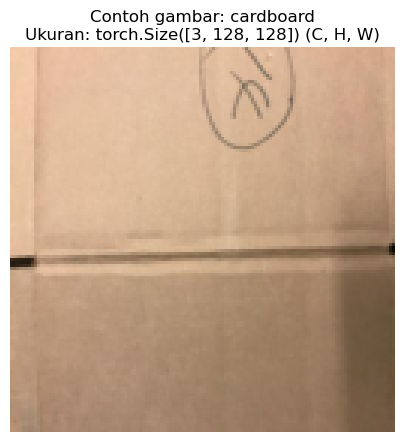

Sebagian nilai piksel channel Red (sebelum normalisasi, skala 0-255):
[[243. 243. 243. 243. 242.]
 [245. 245. 243. 243. 243.]
 [242. 245. 244. 242. 241.]
 [244. 243. 243. 241. 241.]
 [243. 244. 242. 242. 244.]]


In [27]:
# Tunjukkan satu gambar contoh + matriks angkanya
def imshow_tensor(img_tensor):
    """img_tensor sudah dinormalisasi, kembalikan ke range 0-1 untuk ditampilkan"""
    img = img_tensor.numpy().transpose((1, 2, 0))  # CHW -> HWC
    img = img * 0.5 + 0.5  # un-normalize
    return np.clip(img, 0, 1)

sample_img, sample_label = full_dataset[0]

plt.figure(figsize=(5, 5))
plt.imshow(imshow_tensor(sample_img))
plt.title(f"Contoh gambar: {class_names[sample_label]}\nUkuran: {sample_img.shape} (C, H, W)")
plt.axis("off")
plt.show()

# Tampilkan sebagian kecil matriks angka dari channel Red
print("Sebagian nilai piksel channel Red (sebelum normalisasi, skala 0-255):")
red_channel = (sample_img[0] * 0.5 + 0.5) * 255
print(red_channel[:5, :5].round().numpy())


---
## STEP 2/7 — Convolution: Filter yang Menggeser

Layer **Conv2d** menggeser filter (kernel) kecil, misal 3x3, ke seluruh area gambar. Pada tiap posisi:

$$\text{output} = \sum (\text{piksel} \times \text{bobot filter})$$

Hasil dari operasi ini disebut **feature map**. Filter inilah yang dipelajari (di-update) selama training agar bisa mendeteksi tepi, tekstur, dan pola yang relevan untuk membedakan jenis-jenis sampah (cardboard, glass, metal, paper, plastic, trash).

Di PyTorch, layer ini ditulis sebagai `nn.Conv2d(in_channels, out_channels, kernel_size)`.


In [28]:
# Demonstrasi manual: 1 filter edge-detector 3x3 diterapkan pada potongan kecil gambar
edge_filter = torch.tensor([
    [1., 0., -1.],
    [1., 0., -1.],
    [1., 0., -1.]
])

# Ambil patch 3x3 dari channel Red gambar contoh (skala 0-255)
patch = red_channel[10:13, 10:13]
hasil = (patch * edge_filter).sum()

print("Patch 3x3 dari gambar:")
print(patch.numpy())
print("\nFilter edge detector 3x3:")
print(edge_filter.numpy())
print(f"\nHasil konvolusi (sum elemen-wise multiplication) = {hasil.item():.2f}")


Patch 3x3 dari gambar:
[[225. 232. 231.]
 [223. 230. 231.]
 [226. 227. 230.]]

Filter edge detector 3x3:
[[ 1.  0. -1.]
 [ 1.  0. -1.]
 [ 1.  0. -1.]]

Hasil konvolusi (sum elemen-wise multiplication) = -18.00


Input shape : torch.Size([1, 3, 128, 128])
Output shape (4 feature map): torch.Size([1, 4, 128, 128])


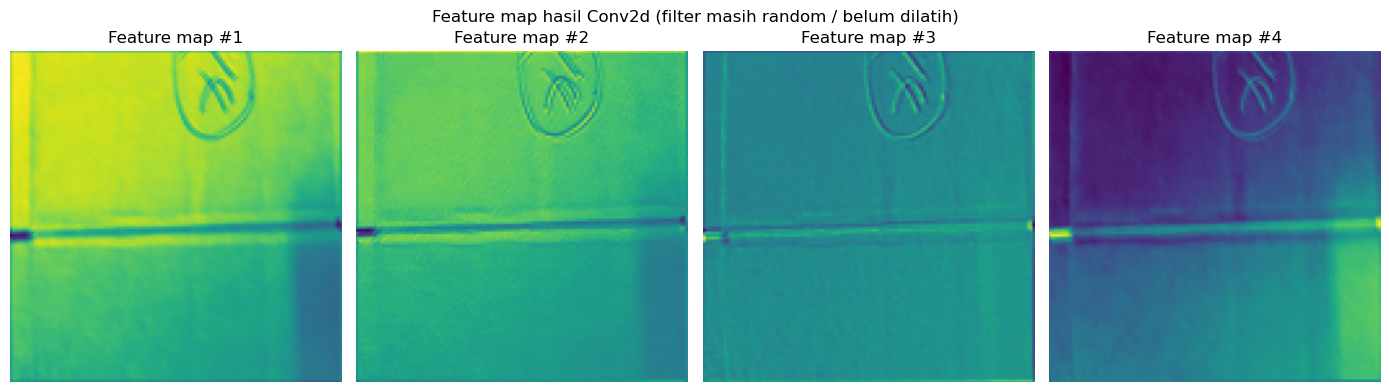

In [29]:
# Terapkan Conv2d sungguhan dari PyTorch pada gambar contoh, lihat feature map-nya
demo_conv = nn.Conv2d(in_channels=3, out_channels=4, kernel_size=3, padding=1)

with torch.no_grad():
    input_batch = sample_img.unsqueeze(0)        # tambah dimensi batch -> (1, C, H, W)
    feature_maps = demo_conv(input_batch)        # -> (1, 4, H, W)

print("Input shape :", input_batch.shape)
print("Output shape (4 feature map):", feature_maps.shape)

fig, axes = plt.subplots(1, 4, figsize=(14, 4))
for i in range(4):
    axes[i].imshow(feature_maps[0, i].numpy(), cmap="viridis")
    axes[i].set_title(f"Feature map #{i+1}")
    axes[i].axis("off")
plt.suptitle("Feature map hasil Conv2d (filter masih random / belum dilatih)")
plt.tight_layout()
plt.show()


---
## STEP 3/7 — Hierarki Fitur: Apa yang Dilihat CNN

Hasil konvolusi disebut **feature map**. CNN biasanya menumpuk banyak layer Conv, dan tiap layer "melihat" tingkat abstraksi berbeda:

| Layer | Yang Dideteksi | Contoh |
|---|---|---|
| Awal | Garis & tepi | edges, curves |
| Tengah | Bentuk & tekstur | shapes, textures |
| Dalam | Objek & fitur kompleks | bentuk botol, kemasan kaleng, lipatan kertas/karton |

Semakin dalam layer-nya, semakin kompleks dan semakin spesifik fitur yang dipelajari terhadap tugas klasifikasi (cardboard / glass / metal / paper / plastic / trash).


---
## STEP 4/7 — ReLU: Buang yang Negatif

**ReLU (Rectified Linear Unit)** adalah fungsi aktivasi sederhana:

$$f(x) = \max(0, x)$$

Semua nilai negatif pada feature map diubah jadi 0, nilai positif dibiarkan apa adanya. Tujuannya agar jaringan hanya fokus pada sinyal yang "menyala" (aktif/penting), dan agar model bisa mempelajari hubungan non-linear (tanpa ReLU, CNN hanya akan jadi kombinasi linear yang lemah).

Di PyTorch: `nn.ReLU()` atau `F.relu(x)`.


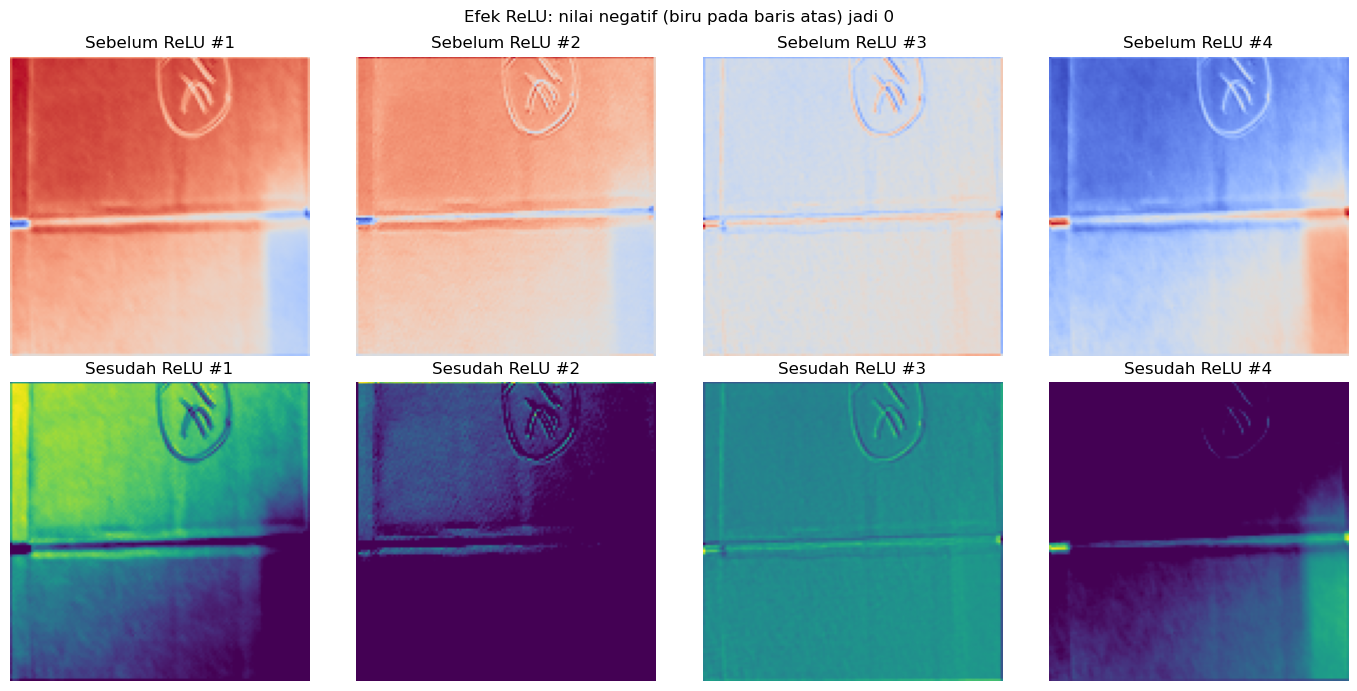

Jumlah nilai negatif sebelum ReLU : 20228
Jumlah nilai negatif sesudah ReLU : 0


In [30]:
# Demonstrasi ReLU pada feature map dari Step 2
with torch.no_grad():
    after_relu = F.relu(feature_maps)

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for i in range(4):
    axes[0, i].imshow(feature_maps[0, i].numpy(), cmap="coolwarm")
    axes[0, i].set_title(f"Sebelum ReLU #{i+1}")
    axes[0, i].axis("off")

    axes[1, i].imshow(after_relu[0, i].numpy(), cmap="viridis")
    axes[1, i].set_title(f"Sesudah ReLU #{i+1}")
    axes[1, i].axis("off")

plt.suptitle("Efek ReLU: nilai negatif (biru pada baris atas) jadi 0")
plt.tight_layout()
plt.show()

print(f"Jumlah nilai negatif sebelum ReLU : {(feature_maps < 0).sum().item()}")
print(f"Jumlah nilai negatif sesudah ReLU : {(after_relu < 0).sum().item()}")


---
## STEP 5/7 — Max Pooling: Ambil yang Penting Saja

**Max Pooling** mengambil nilai maksimum dari tiap area kecil (misal 2x2) pada feature map. Efeknya:

- Ukuran data berkurang (biasanya jadi 1/4 dari ukuran asli untuk pool 2x2).
- Informasi paling "kuat"/penting tetap dipertahankan.
- Model jadi lebih tahan terhadap pergeseran posisi objek kecil (translation invariance) dan komputasi jadi lebih ringan.

Di PyTorch: `nn.MaxPool2d(kernel_size=2, stride=2)`.


Shape sebelum pooling: torch.Size([1, 4, 128, 128])
Shape sesudah pooling : torch.Size([1, 4, 64, 64])


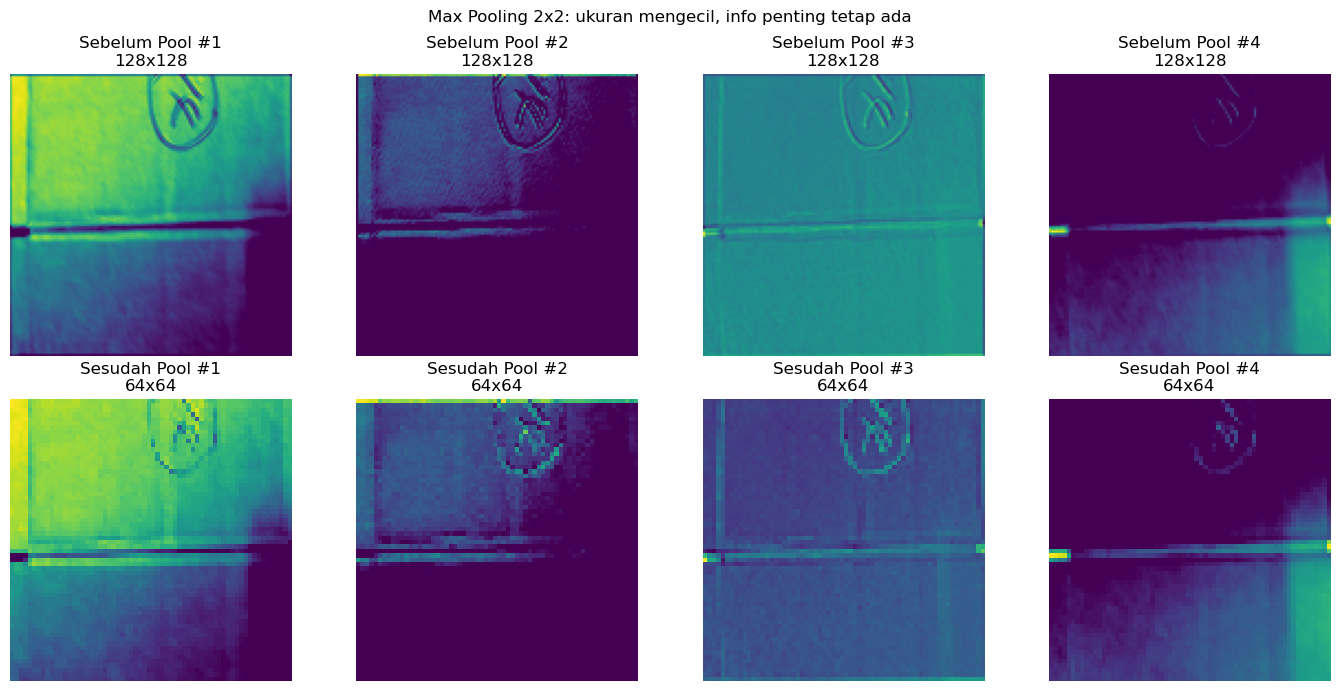

In [31]:
# Demonstrasi MaxPool2d pada feature map sesudah ReLU
pool = nn.MaxPool2d(kernel_size=2, stride=2)

with torch.no_grad():
    pooled = pool(after_relu)

print("Shape sebelum pooling:", after_relu.shape)
print("Shape sesudah pooling :", pooled.shape)

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for i in range(4):
    axes[0, i].imshow(after_relu[0, i].numpy(), cmap="viridis")
    axes[0, i].set_title(f"Sebelum Pool #{i+1}\n{after_relu.shape[2]}x{after_relu.shape[3]}")
    axes[0, i].axis("off")

    axes[1, i].imshow(pooled[0, i].numpy(), cmap="viridis")
    axes[1, i].set_title(f"Sesudah Pool #{i+1}\n{pooled.shape[2]}x{pooled.shape[3]}")
    axes[1, i].axis("off")

plt.suptitle("Max Pooling 2x2: ukuran mengecil, info penting tetap ada")
plt.tight_layout()
plt.show()


---
## STEP 6/7 — Flatten: Dari Grid jadi Baris

Setelah beberapa kali Conv + ReLU + Pool, kita punya feature map 3D berbentuk `(channels, height, width)`. Sebelum masuk ke layer **Fully Connected (FC / Linear)**, feature map ini diratakan (**flatten**) menjadi vektor 1 dimensi.

Di PyTorch: `tensor.view(batch_size, -1)` atau `nn.Flatten()`.


In [32]:
flatten_demo = nn.Flatten()

with torch.no_grad():
    flat = flatten_demo(pooled)

print("Shape sebelum flatten (batch, channel, H, W):", pooled.shape)
print("Shape sesudah flatten (batch, fitur)        :", flat.shape)
print("\nContoh 10 nilai pertama hasil flatten:")
print(flat[0, :10].numpy().round(3))


Shape sebelum flatten (batch, channel, H, W): torch.Size([1, 4, 64, 64])
Shape sesudah flatten (batch, fitur)        : torch.Size([1, 16384])

Contoh 10 nilai pertama hasil flatten:
[0.56  0.552 0.543 0.535 0.448 0.466 0.482 0.497 0.496 0.506]


---
## STEP 7/7 — Fully Connected + Softmax: Keputusan Akhir

Vektor 1D hasil flatten dimasukkan ke satu atau beberapa **Fully Connected layer** (`nn.Linear`), persis seperti Multi-Layer Perceptron (MLP) biasa.

Layer output terakhir memiliki jumlah neuron = jumlah kelas (6: cardboard, glass, metal, paper, plastic, trash), lalu fungsi **Softmax** mengubah nilai mentah (logits) menjadi probabilitas yang totalnya 100%:

$$\text{Softmax}(z_i) = \frac{e^{z_i}}{\sum_j e^{z_j}}$$

Kelas dengan probabilitas terbesar menjadi prediksi akhir model.

> Catatan: pada PyTorch, fungsi loss `nn.CrossEntropyLoss` sudah menggabungkan Softmax + Negative Log Likelihood, jadi pada model kita layer terakhir cukup mengeluarkan logits mentah (tanpa softmax eksplisit) saat training. Softmax baru diterapkan secara eksplisit saat inferensi/prediksi untuk menampilkan probabilitas.


---
## Membangun Arsitektur CNN Lengkap

Sekarang kita susun seluruh alur (Conv -> ReLU -> Pool, diulang beberapa kali, lalu Flatten -> FC -> Output) menjadi satu kelas model PyTorch.

Arsitektur:

```
Input (3, 64, 64)
  -> Conv2d(3, 16, 3) -> ReLU -> MaxPool2d(2)   -> (16, 32, 32)
  -> Conv2d(16, 32, 3) -> ReLU -> MaxPool2d(2)  -> (32, 16, 16)
  -> Conv2d(32, 64, 3) -> ReLU -> MaxPool2d(2)  -> (64, 8, 8)
  -> Flatten                                     -> (64*8*8)
  -> Linear(64*8*8, 128) -> ReLU
  -> Linear(128, num_classes)                    -> Output (logits)
```


In [33]:
class TrashCNN(nn.Module):
    def __init__(self, num_classes):
        super(TrashCNN, self).__init__()

        # Blok Convolutional
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # Hitung ukuran setelah 3x pooling: IMG_SIZE / (2*2*2)
        feat_size = IMG_SIZE // 8
        self.flatten_dim = 64 * feat_size * feat_size

        # Blok Fully Connected
        self.fc1 = nn.Linear(self.flatten_dim, 128)
        self.fc2 = nn.Linear(128, num_classes)

        self.dropout = nn.Dropout(0.3)

    def forward(self, x):
        # Blok 1: Conv -> ReLU -> Pool
        x = self.pool(F.relu(self.conv1(x)))
        # Blok 2: Conv -> ReLU -> Pool
        x = self.pool(F.relu(self.conv2(x)))
        # Blok 3: Conv -> ReLU -> Pool
        x = self.pool(F.relu(self.conv3(x)))

        # Flatten
        x = x.view(x.size(0), -1)

        # Fully Connected
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)  # logits mentah (Softmax diterapkan saat inferensi)

        return x


model = TrashCNN(num_classes=num_classes).to(device)
print(model)


TrashCNN(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=16384, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=7, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
)


In [34]:
# Cek jumlah parameter yang dapat dilatih
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameter yang dilatih: {total_params:,}")


Total parameter yang dilatih: 2,121,767


---
## Training Model

Kita melatih model menggunakan:

- **Loss function**: `CrossEntropyLoss` (mencakup Softmax secara internal).
- **Optimizer**: `Adam`.
- Evaluasi pada `val_loader` di setiap epoch untuk memantau overfitting.


In [35]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

NUM_EPOCHS = 15

history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

for epoch in range(NUM_EPOCHS):
    # ---- Training ----
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / total
    train_acc = correct / total

    # ---- Validation ----
    model.eval()
    val_running_loss, val_correct, val_total = 0.0, 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            val_correct += (predicted == labels).sum().item()
            val_total += labels.size(0)

    val_loss = val_running_loss / val_total
    val_acc = val_correct / val_total

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"Epoch [{epoch+1}/{NUM_EPOCHS}] "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")


Epoch [1/15] Train Loss: 1.5452 Acc: 0.3876 | Val Loss: 1.2420 Acc: 0.5433
Epoch [2/15] Train Loss: 1.2148 Acc: 0.5447 | Val Loss: 1.0890 Acc: 0.5669
Epoch [3/15] Train Loss: 1.0213 Acc: 0.6349 | Val Loss: 1.0039 Acc: 0.6181
Epoch [4/15] Train Loss: 0.9249 Acc: 0.6619 | Val Loss: 0.8952 Acc: 0.6890
Epoch [5/15] Train Loss: 0.8135 Acc: 0.7120 | Val Loss: 0.9454 Acc: 0.6693
Epoch [6/15] Train Loss: 0.6871 Acc: 0.7615 | Val Loss: 0.7942 Acc: 0.7126
Epoch [7/15] Train Loss: 0.6197 Acc: 0.7831 | Val Loss: 0.8847 Acc: 0.7047
Epoch [8/15] Train Loss: 0.4910 Acc: 0.8283 | Val Loss: 0.8402 Acc: 0.7047
Epoch [9/15] Train Loss: 0.3956 Acc: 0.8592 | Val Loss: 0.8584 Acc: 0.7323
Epoch [10/15] Train Loss: 0.3485 Acc: 0.8847 | Val Loss: 0.8044 Acc: 0.7244
Epoch [11/15] Train Loss: 0.2867 Acc: 0.9073 | Val Loss: 1.0264 Acc: 0.7087
Epoch [12/15] Train Loss: 0.2649 Acc: 0.9097 | Val Loss: 0.9694 Acc: 0.7165
Epoch [13/15] Train Loss: 0.2322 Acc: 0.9200 | Val Loss: 0.9725 Acc: 0.7244
Epoch [14/15] Train L

---
## Visualisasi Hasil Training

Grafik loss dan akurasi membantu kita melihat apakah model belajar dengan baik atau mengalami overfitting (train acc tinggi tapi val acc stagnan/menurun).


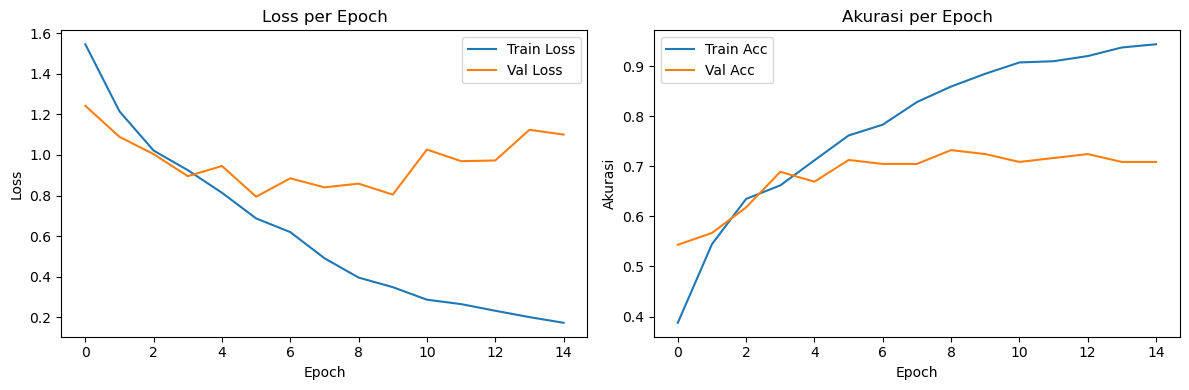

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history["train_loss"], label="Train Loss")
axes[0].plot(history["val_loss"], label="Val Loss")
axes[0].set_title("Loss per Epoch")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(history["train_acc"], label="Train Acc")
axes[1].plot(history["val_acc"], label="Val Acc")
axes[1].set_title("Akurasi per Epoch")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Akurasi")
axes[1].legend()

plt.tight_layout()
plt.show()


---
## Evaluasi pada Test Set

Sekarang model dievaluasi pada data test (data yang belum pernah dilihat sama sekali selama training maupun validasi), termasuk **confusion matrix** dan **classification report** (precision, recall, f1-score per kelas).


In [37]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_acc = (np.array(all_preds) == np.array(all_labels)).mean()
print(f"Test Accuracy: {test_acc:.4f}")

print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=class_names))


Test Accuracy: 0.6406

Classification Report:
              precision    recall  f1-score   support

   cardboard       0.71      0.87      0.78        39
       glass       0.58      0.63      0.61        57
       metal       0.48      0.51      0.50        49
       paper       0.93      0.64      0.76        61
     plastic       0.60      0.68      0.63        37
   tesfolder       0.00      0.00      0.00         2
       trash       0.62      0.45      0.53        11

    accuracy                           0.64       256
   macro avg       0.56      0.54      0.54       256
weighted avg       0.66      0.64      0.64       256



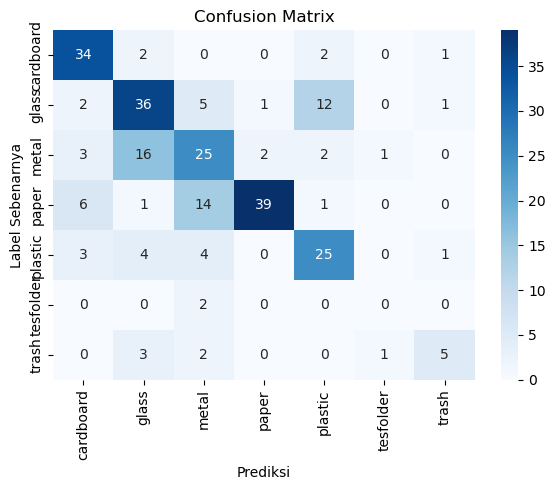

In [38]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Prediksi")
plt.ylabel("Label Sebenarnya")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()


---
## Inferensi Akhir: Prediksi dengan Probabilitas (Softmax)

Bagian ini mendemonstrasikan **Step 7** secara nyata: mengambil satu gambar dari test set, lewatkan ke model, lalu terapkan **Softmax** secara eksplisit untuk mendapatkan probabilitas tiap kelas, mirip seperti contoh "Plastic 89%, Metal 7%, Paper 3%, Cardboard 1%".


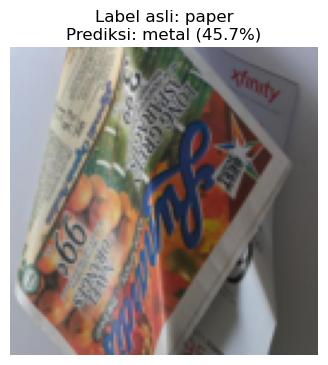

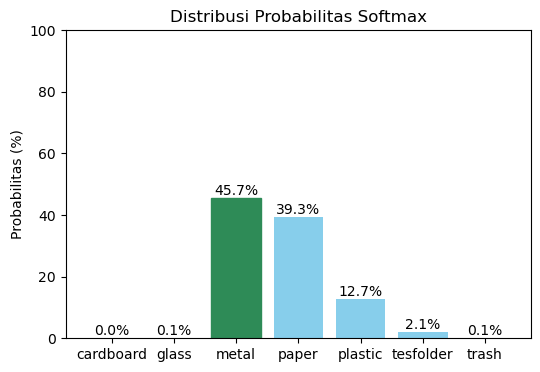

Total probabilitas (harus = 100%): 100.0 %


In [39]:
def predict_image(model, image_tensor, class_names):
    model.eval()
    with torch.no_grad():
        image_tensor = image_tensor.unsqueeze(0).to(device)
        logits = model(image_tensor)
        probs = F.softmax(logits, dim=1).cpu().numpy()[0]
    return probs

# Ambil 1 sample acak dari test set
sample_idx = random.randint(0, len(test_set) - 1)
img_tensor, true_label = test_set[sample_idx]

probs = predict_image(model, img_tensor, class_names)
pred_label = np.argmax(probs)

# Tampilkan gambar
plt.figure(figsize=(4, 4))
plt.imshow(imshow_tensor(img_tensor))
plt.title(f"Label asli: {class_names[true_label]}\nPrediksi: {class_names[pred_label]} ({probs[pred_label]*100:.1f}%)")
plt.axis("off")
plt.show()

# Tampilkan bar chart probabilitas (mirip contoh Plastic 89%, dst)
plt.figure(figsize=(6, 4))
bars = plt.bar(class_names, probs * 100, color="skyblue")
bars[pred_label].set_color("seagreen")
plt.ylabel("Probabilitas (%)")
plt.title("Distribusi Probabilitas Softmax")
plt.ylim(0, 100)
for i, p in enumerate(probs * 100):
    plt.text(i, p + 1, f"{p:.1f}%", ha="center")
plt.show()

print("Total probabilitas (harus = 100%):", round(probs.sum() * 100, 2), "%")


---
## Tes Model dengan Gambar Baru (Upload Sendiri)

Bagian ini untuk mengetes model menggunakan foto sampah yang **belum pernah dilihat sama sekali** oleh model (di luar dataset training/validation/test). Ini cara paling realistis untuk mengecek apakah model benar-benar bisa generalisasi.

Cara pakai:
1. Siapkan file gambar (jpg/png) foto sampah.
2. Ubah variabel `TEST_IMAGE_PATH` di bawah ke path file tersebut.
3. Jalankan cell-nya — hasil prediksi dan probabilitas tiap kelas akan ditampilkan.


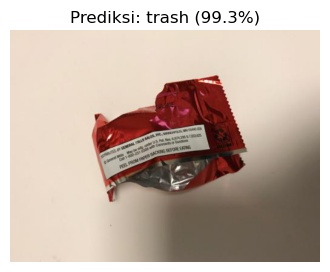

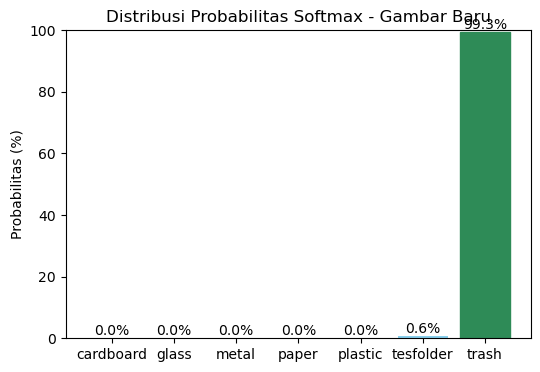

cardboard : 0.00%
glass     : 0.01%
metal     : 0.02%
paper     : 0.00%
plastic   : 0.00%
tesfolder : 0.64%
trash     : 99.33%


In [40]:
from PIL import Image

TEST_IMAGE_PATH = "trash_003.jpg"  # <-- ganti dengan path foto kamu

def predict_new_image(path, model, class_names):
    img = Image.open(path).convert("RGB")
    img_tensor = transform(img)  # pakai transform yang sama dengan training

    model.eval()
    with torch.no_grad():
        logits = model(img_tensor.unsqueeze(0).to(device))
        probs = F.softmax(logits, dim=1).cpu().numpy()[0]

    pred_idx = np.argmax(probs)
    return img, probs, pred_idx

img, probs, pred_idx = predict_new_image(TEST_IMAGE_PATH, model, class_names)

# Tampilkan gambar + hasil prediksi
plt.figure(figsize=(4, 4))
plt.imshow(img)
plt.title(f"Prediksi: {class_names[pred_idx]} ({probs[pred_idx]*100:.1f}%)")
plt.axis("off")
plt.show()

# Bar chart probabilitas
plt.figure(figsize=(6, 4))
bars = plt.bar(class_names, probs * 100, color="skyblue")
bars[pred_idx].set_color("seagreen")
plt.ylabel("Probabilitas (%)")
plt.title("Distribusi Probabilitas Softmax - Gambar Baru")
plt.ylim(0, 100)
for i, p in enumerate(probs * 100):
    plt.text(i, p + 1, f"{p:.1f}%", ha="center")
plt.show()

for cls, p in zip(class_names, probs):
    print(f"{cls:10s}: {p*100:.2f}%")


### Tes Banyak Gambar Sekaligus (Batch)

Jika punya beberapa foto sekaligus dalam satu folder, gunakan cell berikut untuk menguji semuanya dan menampilkan hasilnya dalam grid.


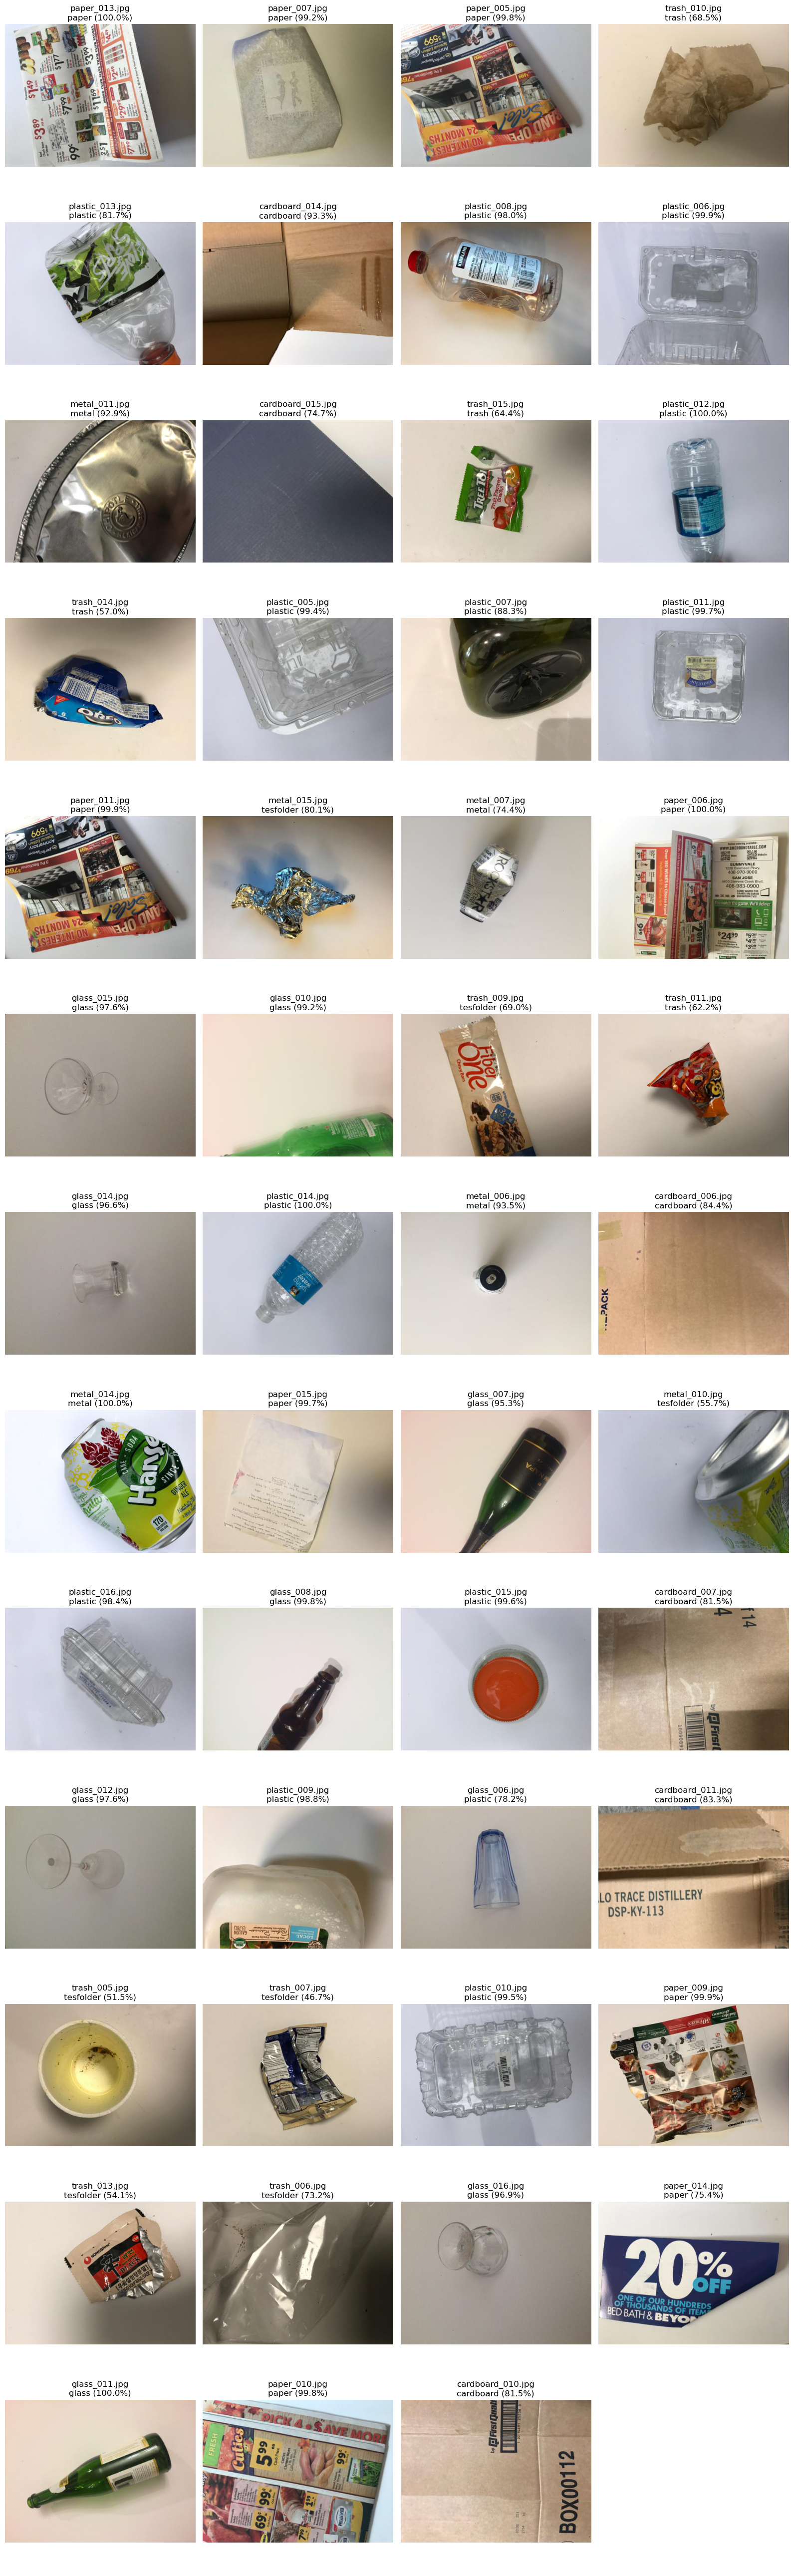

In [41]:
import glob

TEST_FOLDER = "tesfolder"  # <-- folder berisi beberapa gambar untuk dites

image_paths = glob.glob(os.path.join(TEST_FOLDER, "*"))
image_paths = [p for p in image_paths if p.lower().endswith((".jpg", ".jpeg", ".png"))]

if len(image_paths) == 0:
    print(f"Tidak ada gambar ditemukan di folder '{TEST_FOLDER}'.")
else:
    n = len(image_paths)
    cols = min(4, n)
    rows = (n + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 4*rows))
    axes = np.array(axes).reshape(-1)

    for i, path in enumerate(image_paths):
        img, probs, pred_idx = predict_new_image(path, model, class_names)
        axes[i].imshow(img)
        axes[i].set_title(f"{os.path.basename(path)}\n{class_names[pred_idx]} ({probs[pred_idx]*100:.1f}%)")
        axes[i].axis("off")

    # Sembunyikan axes kosong jika ada
    for j in range(len(image_paths), len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()


---
## Menyimpan Model

Simpan bobot model (`state_dict`) agar bisa digunakan kembali tanpa training ulang.


In [42]:
torch.save(model.state_dict(), "trash_cnn_model.pth")
print("Model disimpan sebagai trash_cnn_model.pth")

# Cara load kembali:
# model_loaded = TrashCNN(num_classes=num_classes)
# model_loaded.load_state_dict(torch.load("trash_cnn_model.pth", map_location=device))
# model_loaded.to(device)
# model_loaded.eval()


Model disimpan sebagai trash_cnn_model.pth


---
## Ringkasan Alur CNN

| Tahap | Fungsi |
|---|---|
| **Input** | Gambar dipecah jadi matriks angka 0–255, di-resize & dinormalisasi |
| **Conv** | Filter mendeteksi tepi, bentuk, dan pola -> menghasilkan feature map |
| **ReLU** | Membuang nilai negatif, model fokus pada sinyal penting & non-linear |
| **Pool** | Mengompres ukuran feature map, mempertahankan info penting (translation invariance) |
| **Flatten** | Mengubah feature map 2D/3D menjadi vektor 1D |
| **FC + Softmax** | Mengambil keputusan akhir berupa probabilitas tiap kelas, totalnya 100% |

Notebook ini mengimplementasikan seluruh alur tersebut dengan PyTorch untuk klasifikasi 6 jenis sampah pada dataset **TrashType_Image_Dataset**: **cardboard, glass, metal, paper, plastic, trash**.
